# Build and train your first CNN

**Learning objective:** Train a compact Fashion-MNIST CNN and read its learning curves and test accuracy.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:15:50.049664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974950.064692    3917 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974950.069021    3917 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:15:51.818580: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
(x,y),(xt,yt)=tf.keras.datasets.fashion_mnist.load_data(); x=x[:5000].astype("float32")/255; y=y[:5000]; xt=xt[:1000].astype("float32")/255; yt=yt[:1000]
x=x[...,None]; xt=xt[...,None]
model=tf.keras.Sequential([tf.keras.layers.Input((28,28,1)),tf.keras.layers.Conv2D(16,3,activation="relu"),tf.keras.layers.MaxPooling2D(),tf.keras.layers.Conv2D(32,3,activation="relu"),tf.keras.layers.MaxPooling2D(),tf.keras.layers.Flatten(),tf.keras.layers.Dense(32,activation="relu"),tf.keras.layers.Dense(10,activation="softmax")])
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
hist=model.fit(x,y,validation_split=.2,epochs=2,batch_size=64,verbose=0)
loss,acc=model.evaluate(xt,yt,verbose=0); display(pd.DataFrame(hist.history).round(4)); print("held-out test accuracy:",round(float(acc),4))


,accuracy,loss,val_accuracy,val_loss
0,0.4877,1.5519,0.70,0.8203
1,0.7230,0.7879,0.77,0.6329


held-out test accuracy: 0.716


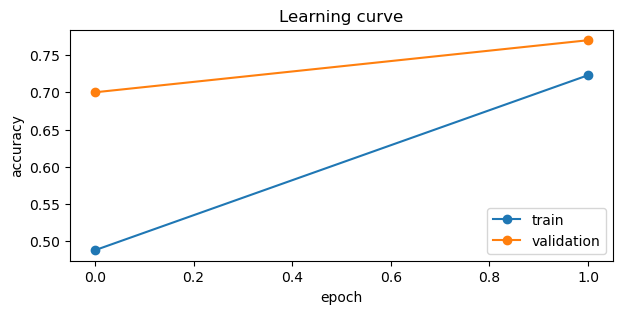

In [3]:
h=pd.DataFrame(hist.history); plt.figure(figsize=(7,3)); plt.plot(h["accuracy"],marker="o",label="train"); plt.plot(h["val_accuracy"],marker="o",label="validation"); plt.legend(); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Learning curve"); plt.show()
